In [15]:
import numpy as np

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Регуляризация (C = 1/lambda)
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Превращаем метки 0/1 в -1/1
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Условие корректной классификации с учетом отступа
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Только штраф за веса (L2 регуляризация)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Штраф за веса + ошибка классификации (Hinge Loss)
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [17]:
# Загрузка и подготовка данных
data = datasets.load_breast_cancer()
X, y = data.data, data.target

# SVM чувствителен к масштабу признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [18]:
# Определение сетки параметров
param_grid = {
    'C': [0.1, 1, 10, 100],            # Параметр мягкого отступа
    'gamma': [1, 0.1, 0.01, 0.001],    # Коэффициент ядра (для rbf, poly, sigmoid)
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Поиск лучших параметров с кросс-валидацией
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

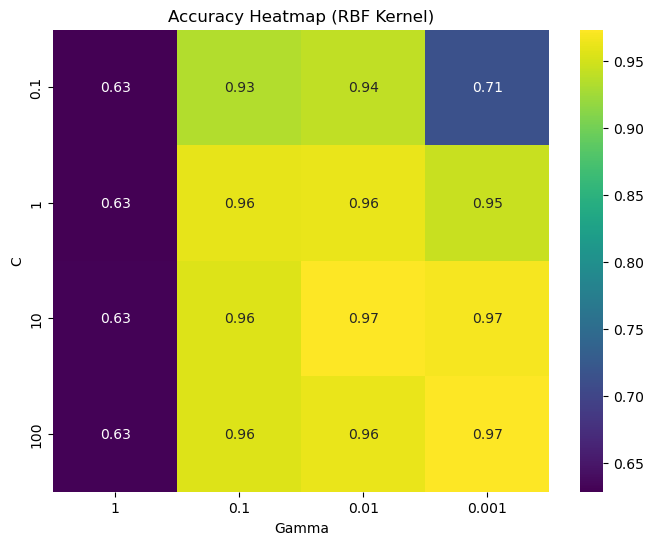

Лучшие параметры: {'C': 100, 'gamma': 0.001, 'kernel': 'sigmoid'}
Точность на тестовой выборке: 0.9825


In [19]:
# Визуализация тепловой карты (для ядра RBF)
# Извлекаем результаты и меняем форму для Heatmap
results = grid.cv_results_
# Выбираем только результаты, где kernel == 'rbf'
scores = results['mean_test_score'][results['param_kernel'] == 'rbf'].reshape(4, 4)

plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'], cmap='viridis')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.title('Accuracy Heatmap (RBF Kernel)')
plt.show()

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Точность на тестовой выборке: {grid.score(X_test, y_test):.4f}")

# Контекст:
В астрономии классификация звезд — это классификация звезд на основе их спектральных характеристик. Схема классификации галактик, квазаров и звезд является одной из самых фундаментальных в астрономии. Ранняя каталогизация звезд и их распределения на небе привела к пониманию того, что они составляют нашу собственную галактику, и после того, как было установлено, что Андромеда является отдельной галактикой от нашей, многие галактики начали изучаться по мере создания более мощных телескопов. Цель этого спутника данных — классифицировать звезды, галактики и квазары на основе их спектральных характеристик.

# Содержание:

Данные состоят из 100 000 наблюдений космического пространства, выполненных в рамках проекта SDSS (Sloan Digital Sky Survey). Каждое наблюдение описывается 17 столбцами характеристик и 1 столбцом класса, который определяет, является ли оно звездой, галактикой или квазаром.

# Задание:
Выполнить предобработку данных: обработать выбросы и пропущенные значения (если они есть)

Использовать алгоритм SVM, построить тепловую карту для подбора значений gamma и C

Вывести наилучшую точность модели

In [20]:
# obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
# alpha = Right Ascension angle (at J2000 epoch)
# delta = Declination angle (at J2000 epoch)
# u = Ultraviolet filter in the photometric system
# g = Green filter in the photometric system
# r = Red filter in the photometric system
# i = Near Infrared filter in the photometric system
# z = Infrared filter in the photometric system
# run_ID = Run Number used to identify the specific scan
# rereun_ID = Rerun Number to specify how the image was processed
# cam_col = Camera column to identify the scanline within the run
# field_ID = Field number to identify each field
# spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
# class = object class (galaxy, star or quasar object)
# redshift = redshift value based on the increase in wavelength
# plate = plate ID, identifies each plate in SDSS
# MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
# fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('star_classification.csv').dropna()

In [27]:
X = df[['u', 'g', 'r', 'i', 'z', 'redshift']][:5000]
y = df['class'][:5000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.854 total time=   0.2s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.859 total time=   0.2s
[CV 4/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.600 total time=   0.2s
[CV 1/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.600 total time=   0.2s
[CV 2/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.600 total time=   0.2s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.807 total time=   0.2s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.877 total time=   0.2s
[CV 5/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.600 total time=   0.2s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.845 total time=   0.2s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.835 total time=   0.3s
[CV 3/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.600 total time=   0.2s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

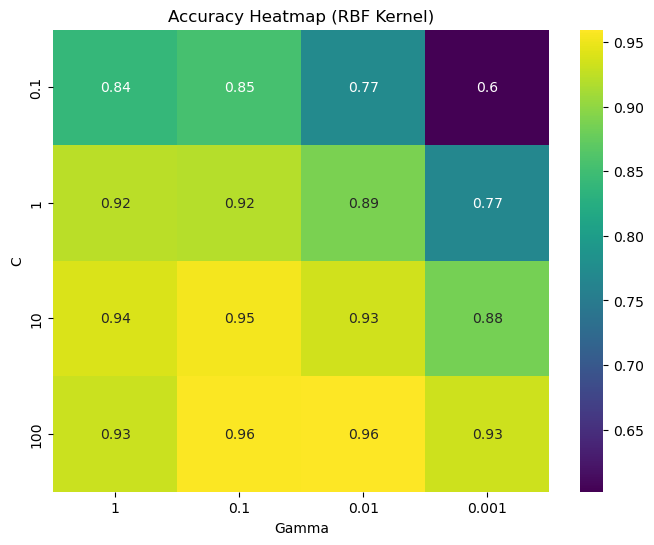

Лучшие параметры: {'C': 0.1, 'gamma': 1, 'kernel': 'poly'}
Точность на тестовой выборке: 0.9550


In [26]:
results = grid.cv_results_

scores = results['mean_test_score'][results['param_kernel'] == 'rbf'].reshape(4, 4)

plt.figure(figsize=(8, 6))
sns.heatmap(scores, annot=True, xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'], cmap='viridis')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.title('Accuracy Heatmap (RBF Kernel)')
plt.show()

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Точность на тестовой выборке: {grid.score(X_test, y_test):.4f}")